In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("email_spam_detection.csv")

In [3]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(7000, 9)


In [4]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB
None

Statistical Summary:
           Email_ID Sender_Email    Subject  Email_Length    Num_Links  \
count   7000.000000         6999       7000   6959.000000  7000.000000   
unique          NaN         6973          8           NaN          NaN   
top             NaN               Win Prize   

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64


In [6]:
df["Sender_Email"] = df["Sender_Email"].replace("", np.nan)

print(df["Sender_Email"].isnull().sum())

1


In [7]:
df = df.dropna(subset=["Sender_Email"])

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (6999, 9)


In [10]:
print(df.dtypes)

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object


In [11]:
df["Email_Length"] = pd.to_numeric(df["Email_Length"], errors="coerce")
df["Num_Special_Chars"] = pd.to_numeric(df["Num_Special_Chars"], errors="coerce")
df["Num_Links"] = pd.to_numeric(df["Num_Links"], errors="coerce")

In [12]:
print(df[df["Email_Length"].isnull()])

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                                     Meeting           NaN   
173        174   user173@outlook.com        Project Update           NaN   
346        347   user346@outlook.com             Greetings           NaN   
519        520     user519@gmail.com             Greetings           NaN   
692        693     user692@gmail.com               Meeting           NaN   
865        866     user865@gmail.com               Invoice           NaN   
1038      1039  user1038@company.com             Win Prize           NaN   
1211      1212  user1211@company.com  Account Verification           NaN   
1384      1385  user1384@outlook.com        Project Update           NaN   
1557      1558  user1557@outlook.com  Account Verification           NaN   
1730      1731  user1730@company.com             Greetings           NaN   
1903      1904  user1903@outlook.com             Greetings           NaN   
2076      20

In [13]:
print(df[df["Num_Special_Chars"] == -1])

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                                     Meeting           NaN   
311        312     user311@yahoo.com        Security Alert          40.0   
622        623   user622@company.com               Meeting         184.0   
933        934     user933@yahoo.com               Meeting          98.0   
1244      1245  user1244@company.com             Greetings         180.0   
1555      1556    user1555@gmail.com                 Offer          67.0   
1866      1867  user1866@outlook.com               Invoice          64.0   
2177      2178    user2177@yahoo.com               Invoice         156.0   
2488      2489  user2488@company.com               Meeting          88.0   
2799      2800    user2799@yahoo.com               Meeting         169.0   
3110      3111  user3110@company.com  Account Verification          86.0   
3421      3422  user3421@outlook.com             Win Prize         224.0   
3732      37

In [14]:
df["Num_Special_Chars"] = df["Num_Special_Chars"].replace(-1, np.nan)

In [15]:
print(df[df["Num_Links"] == 99])

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                                     Meeting           NaN   
419        420   user419@outlook.com        Project Update         221.0   
838        839     user838@gmail.com  Account Verification         190.0   
1257      1258  user1257@outlook.com               Meeting          75.0   
1676      1677    user1676@gmail.com        Project Update          88.0   
2095      2096  user2095@outlook.com                 Offer         169.0   
2514      2515  user2514@company.com               Meeting          52.0   
2933      2934    user2933@yahoo.com             Greetings          23.0   
3352      3353    user3352@gmail.com             Win Prize         120.0   
3771      3772  user3771@outlook.com               Invoice          27.0   
4190      4191    user4190@yahoo.com               Invoice         161.0   
4609      4610    user4609@yahoo.com               Meeting          76.0   
5028      50

In [16]:
df["Num_Links"] = df["Num_Links"].replace(99, np.nan)

In [17]:
print(df.isnull().sum())

Email_ID              0
Sender_Email          0
Subject               0
Email_Length         41
Num_Links            17
Num_Special_Chars    23
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64


In [18]:
df["Email_Length"] = df["Email_Length"].fillna(df["Email_Length"].median())

df["Num_Special_Chars"] = df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median())

df["Num_Links"] = df["Num_Links"].fillna(df["Num_Links"].median())

In [19]:
print(df.isnull().sum())

Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
dtype: int64


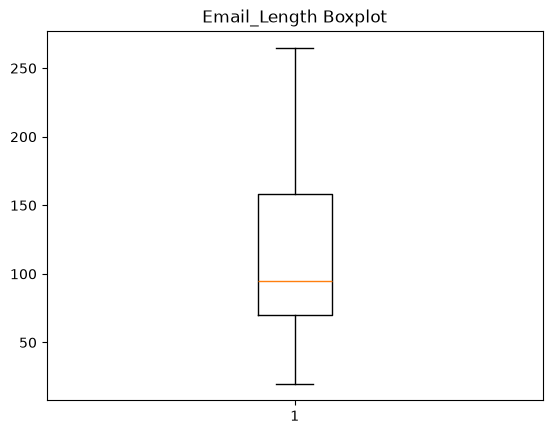

In [20]:
plt.boxplot(df["Email_Length"])
plt.title("Email_Length Boxplot")
plt.show()

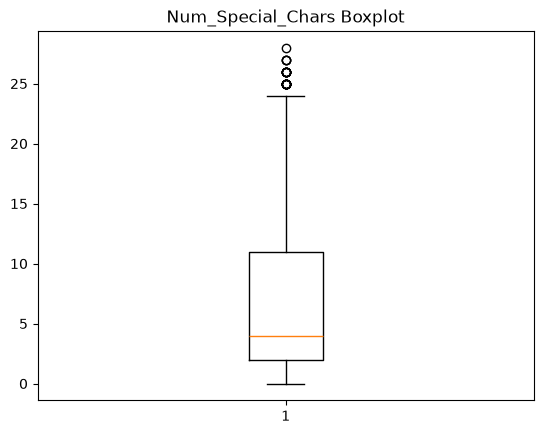

In [21]:
plt.boxplot(df["Num_Special_Chars"])
plt.title("Num_Special_Chars Boxplot")
plt.show()

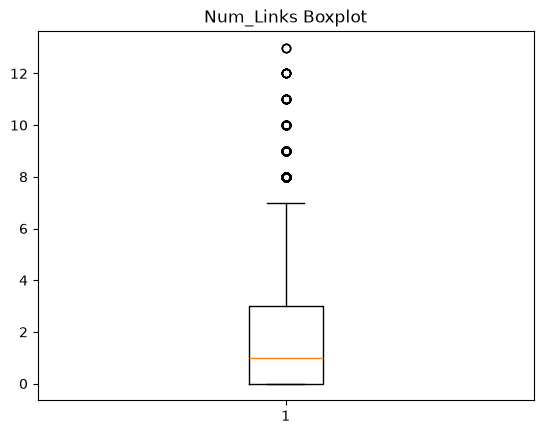

In [22]:
plt.boxplot(df["Num_Links"])
plt.title("Num_Links Boxplot")
plt.show()

In [23]:
Q1 = df["Email_Length"].quantile(0.25)
Q3 = df["Email_Length"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Email_Length"] < lower) | (df["Email_Length"] > upper)]

print(outliers)

Empty DataFrame
Columns: [Email_ID, Sender_Email, Subject, Email_Length, Num_Links, Num_Special_Chars, Capital_Words, Has_Attachment, Spam]
Index: []


In [24]:
df = df[(df["Email_Length"] >= lower) & (df["Email_Length"] <= upper)]

print(df.shape)

(6999, 9)


In [25]:
print(df["Spam"].value_counts())

Spam
0    4864
1    2135
Name: count, dtype: int64


In [26]:
df.to_csv("email_spam_detection_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
